# 第 8 章 · MLPClassifier 代码实验

[章节网页](../ch8.html)

## 运行内容

- 训练 Digits 手写数字分类器
- 查看混淆矩阵
- 绘制 loss 和样本预测

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 加载 sklearn digits：8x8 手写数字分类是神经网络入门的经典案例。
digits = load_digits()
X_mlp = digits.data / 16.0
y_mlp = digits.target

X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(
    X_mlp,
    y_mlp,
    test_size=0.25,
    stratify=y_mlp,
    random_state=8,
)

digits_summary = pd.DataFrame(
    {
        "样本数": [len(X_mlp)],
        "输入维度": [X_mlp.shape[1]],
        "类别数": [len(np.unique(y_mlp))],
        "训练样本": [len(X_train_mlp)],
        "测试样本": [len(X_test_mlp)],
    }
)
display(digits_summary)
display(pd.DataFrame(X_mlp[:5]).round(2))

,样本数,输入维度,类别数,训练样本,测试样本
0,1797,64,10,1347,450


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,0.31,0.81,0.56,0.06,0.0,0.0,0.0,0.0,...,0.00,0.0,0.0,0.0,0.38,0.81,0.62,0.00,0.00,0.0
1,0.0,0.0,0.00,0.75,0.81,0.31,0.0,0.0,0.0,0.0,...,0.00,0.0,0.0,0.0,0.00,0.69,1.00,0.62,0.00,0.0
2,0.0,0.0,0.00,0.25,0.94,0.75,0.0,0.0,0.0,0.0,...,0.31,0.0,0.0,0.0,0.00,0.19,0.69,1.00,0.56,0.0
3,0.0,0.0,0.44,0.94,0.81,0.06,0.0,0.0,0.0,0.5,...,0.56,0.0,0.0,0.0,0.44,0.81,0.81,0.56,0.00,0.0
4,0.0,0.0,0.00,0.06,0.69,0.00,0.0,0.0,0.0,0.0,...,0.00,0.0,0.0,0.0,0.00,0.12,1.00,0.25,0.00,0.0


## 1. 训练过程

In [3]:
# 训练 sklearn MLPClassifier，并读取 loss_curve_。
mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        learning_rate_init=0.01,
        max_iter=80,
        random_state=8,
    ),
)

mlp.fit(X_train_mlp, y_train_mlp)
classifier = mlp.named_steps["mlpclassifier"]
mlp_trace = pd.DataFrame(
    {
        "轮次": np.arange(1, len(classifier.loss_curve_) + 1),
        "loss": classifier.loss_curve_,
    }
).round(4)

display(mlp_trace.iloc[[0, 1, 2, 9, 19, len(mlp_trace) - 1]])

,轮次,loss
0,1,1.9268
1,2,0.7238
2,3,0.3285
9,10,0.0431
19,20,0.0110
56,57,0.0016


In [4]:
# 查看测试集预测、准确率和混淆矩阵。
test_pred_mlp = mlp.predict(X_test_mlp)
test_prob_mlp = mlp.predict_proba(X_test_mlp)

score_df = pd.DataFrame(
    [{"数据": "digits 测试集", "accuracy": accuracy_score(y_test_mlp, test_pred_mlp)}]
).round(3)
confusion_df = pd.DataFrame(
    confusion_matrix(y_test_mlp, test_pred_mlp),
    index=[f"真实_{i}" for i in range(10)],
    columns=[f"预测_{i}" for i in range(10)],
)
sample_result = pd.DataFrame(
    {
        "真实": y_test_mlp[:12],
        "预测": test_pred_mlp[:12],
        "预测置信度": np.max(test_prob_mlp[:12], axis=1),
    }
).round(3)

display(score_df)
display(sample_result)
display(confusion_df)

,数据,accuracy
0,digits 测试集,0.984


,真实,预测,预测置信度
0,4,4,1.000
1,2,2,1.000
2,2,2,0.998
3,4,4,1.000
4,7,7,1.000
5,4,4,1.000
6,2,2,0.999
7,9,9,1.000
8,1,1,1.000
9,1,1,0.928


,预测_0,预测_1,预测_2,预测_3,预测_4,预测_5,预测_6,预测_7,预测_8,预测_9
真实_0,45,0,0,0,0,0,0,0,0,0
真实_1,0,46,0,0,0,0,0,0,0,0
真实_2,0,0,44,0,0,0,0,0,0,0
真实_3,0,0,0,45,0,0,0,0,1,0
真实_4,0,0,0,0,45,0,0,0,0,0
真实_5,0,0,0,0,0,45,0,0,0,1
真实_6,0,0,0,0,0,0,45,0,0,0
真实_7,0,0,0,0,0,0,0,44,1,0
真实_8,0,2,0,1,0,0,0,0,40,0
真实_9,0,0,0,0,0,0,0,0,1,44


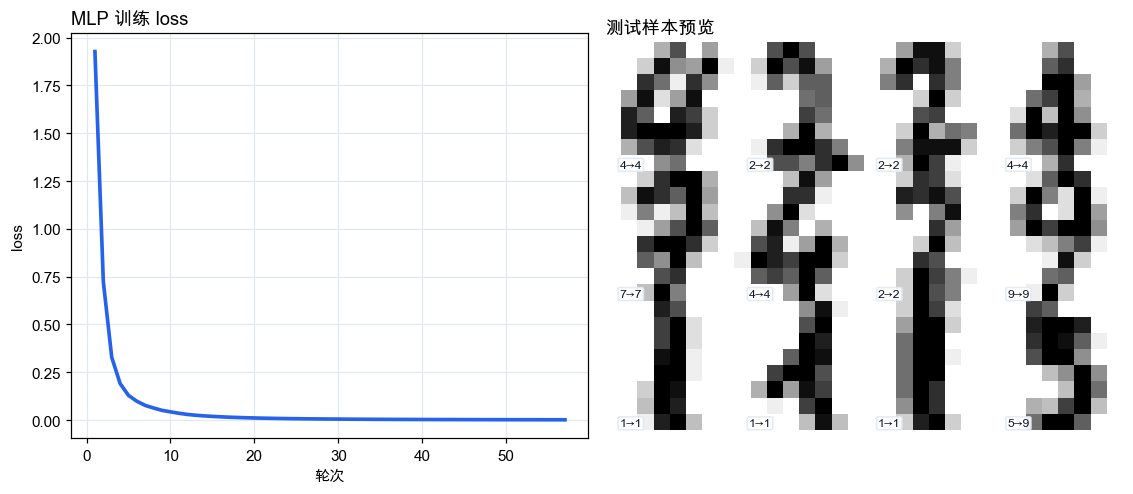

In [5]:
# 绘制 loss 曲线和测试样本预测。
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.6))

axes[0].plot(mlp_trace["轮次"], mlp_trace["loss"], color="#2563eb", linewidth=2.4)
axes[0].set_title("MLP 训练 loss", loc="left", fontweight="bold")
axes[0].set_xlabel("轮次")
axes[0].set_ylabel("loss")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)

preview = X_test_mlp[:12].reshape(-1, 8, 8)
tile = np.block([[preview[i * 4 + j] for j in range(4)] for i in range(3)])
axes[1].imshow(tile, cmap="gray_r")
axes[1].set_title("测试样本预览", loc="left", fontweight="bold")
axes[1].set_xticks([])
axes[1].set_yticks([])
for i in range(12):
    row = i // 4
    col = i % 4
    axes[1].text(
        col * 8 + 0.4,
        row * 8 + 7.3,
        f"{y_test_mlp[i]}→{test_pred_mlp[i]}",
        color="#0f172a",
        fontsize=8,
        bbox={"boxstyle": "round,pad=0.12", "fc": "white", "ec": "#e2e8f0", "alpha": 0.9},
    )
axes[1].axis("off")

plt.tight_layout()
plt.show()